# Hotel Booking Demand — ADR Regression & Explainability

**Project goal:** Predict the **Average Daily Rate (ADR)** of a hotel booking from
its reservation attributes, compare several regression models, select the best one,
and explain *why* it makes its predictions using SHAP.

This notebook runs top-to-bottom and reuses the project's `src/` modules
(`data_loader`, `data_processing`, `modeling`, `pipeline`, `shap_analysis`).

In [1]:
import sys
from pathlib import Path

# Make the project root importable regardless of where the notebook is launched.
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display

from src.data_loader import get_project_root, get_default_hotel_booking_path
from src.pipeline import (
    load_clean_engineer, build_splits, train_and_compare,
    save_comparison, select_best_tree_model,
)
from src.shap_analysis import compute_shap_values, plot_shap_bar, plot_shap_beeswarm, top_features

ROOT = get_project_root()
REPORTS = ROOT / "reports"
print("Project root:", ROOT)
print("Dataset path:", get_default_hotel_booking_path())

Project root: C:\Users\arjun\hotel_booking_and-conceirge_copilot
Dataset path: C:\Users\arjun\hotel_booking_and-conceirge_copilot\data\hotel_bookings.csv


E:\New folder\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading

In [2]:
# Raw load (before cleaning) just to inspect the source data.
from src.data_loader import load_hotel_booking_data
raw = load_hotel_booking_data(get_default_hotel_booking_path())
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Data Cleaning & Feature Engineering

In [3]:
# load_clean_engineer() = clean (dedupe, impute, fix negatives) + engineer features
# (total_guests, total_nights, arrival_month_num, arrival_quarter, ...) and drops
# high-cardinality identifier columns (country/agent/company/reservation_status).
# Sampling keeps the whole notebook fast and reproducible (random_state=42).
df = load_clean_engineer(sample_size=25000, random_state=42)
print("Cleaned + engineered + sampled shape:", df.shape)
df.head()

Cleaned + engineered + sampled shape: (25000, 34)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,reservation_month,reservation_day_of_week,arrival_month_num,arrival_quarter,total_guests,total_nights
0,City Hotel,0,8,2016,November,47,14,1,1,1,...,103.00,0,1,2016-11-16,11,2,11,4,1,2
1,City Hotel,0,1,2017,March,10,10,2,2,1,...,58.45,0,0,2017-03-14,3,1,3,1,1,4
2,Resort Hotel,0,20,2016,February,6,4,2,5,2,...,30.43,0,0,2016-02-11,2,3,2,1,2,7
3,City Hotel,1,120,2017,January,4,23,1,3,2,...,79.56,0,0,2016-09-25,9,6,1,1,2,4
4,Resort Hotel,0,140,2017,August,34,21,2,5,2,...,166.91,0,0,2017-08-28,8,0,8,3,2,7


## 3. EDA Summary

In [4]:
from src.data_processing import summarize_dataframe
print("Rows x Cols:", df.shape)
print("Missing values total:", int(df.isna().sum().sum()))
print("\nADR (target) summary:")
print(df["adr"].describe().round(2))
df.describe(include="number").T.head(15)

Rows x Cols: (25000, 34)
Missing values total: 0

ADR (target) summary:
count    25000.00
mean       106.98
std         52.41
min          0.00
25%         72.25
50%         99.00
75%        135.00
max        437.00
Name: adr, dtype: float64


,count,mean,std,min,25%,50%,75%,max
is_canceled,25000.0,0.27412,0.446079,0.0,0.0,0.0,1.0,1.0
lead_time,25000.0,80.07328,85.603380,0.0,11.0,50.0,125.0,709.0
arrival_date_year,25000.0,2016.20344,0.688354,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_week_number,25000.0,26.99260,13.596247,1.0,16.0,28.0,37.0,53.0
arrival_date_day_of_month,25000.0,15.80348,8.834604,1.0,8.0,16.0,24.0,31.0
stays_in_weekend_nights,25000.0,1.00424,1.038434,0.0,0.0,1.0,2.0,18.0
stays_in_week_nights,25000.0,2.62132,2.056135,0.0,1.0,2.0,4.0,42.0
adults,25000.0,1.87648,0.590895,0.0,2.0,2.0,2.0,27.0
children,25000.0,0.14276,0.458419,0.0,0.0,0.0,0.0,3.0
babies,25000.0,0.01048,0.103782,0.0,0.0,0.0,0.0,2.0


## 4. Visualizations (existing EDA)

The exploratory figures below were produced during the EDA phase and are stored in
`reports/`. They are displayed here (not regenerated) so the EDA work is preserved.

01_adr_distribution.png


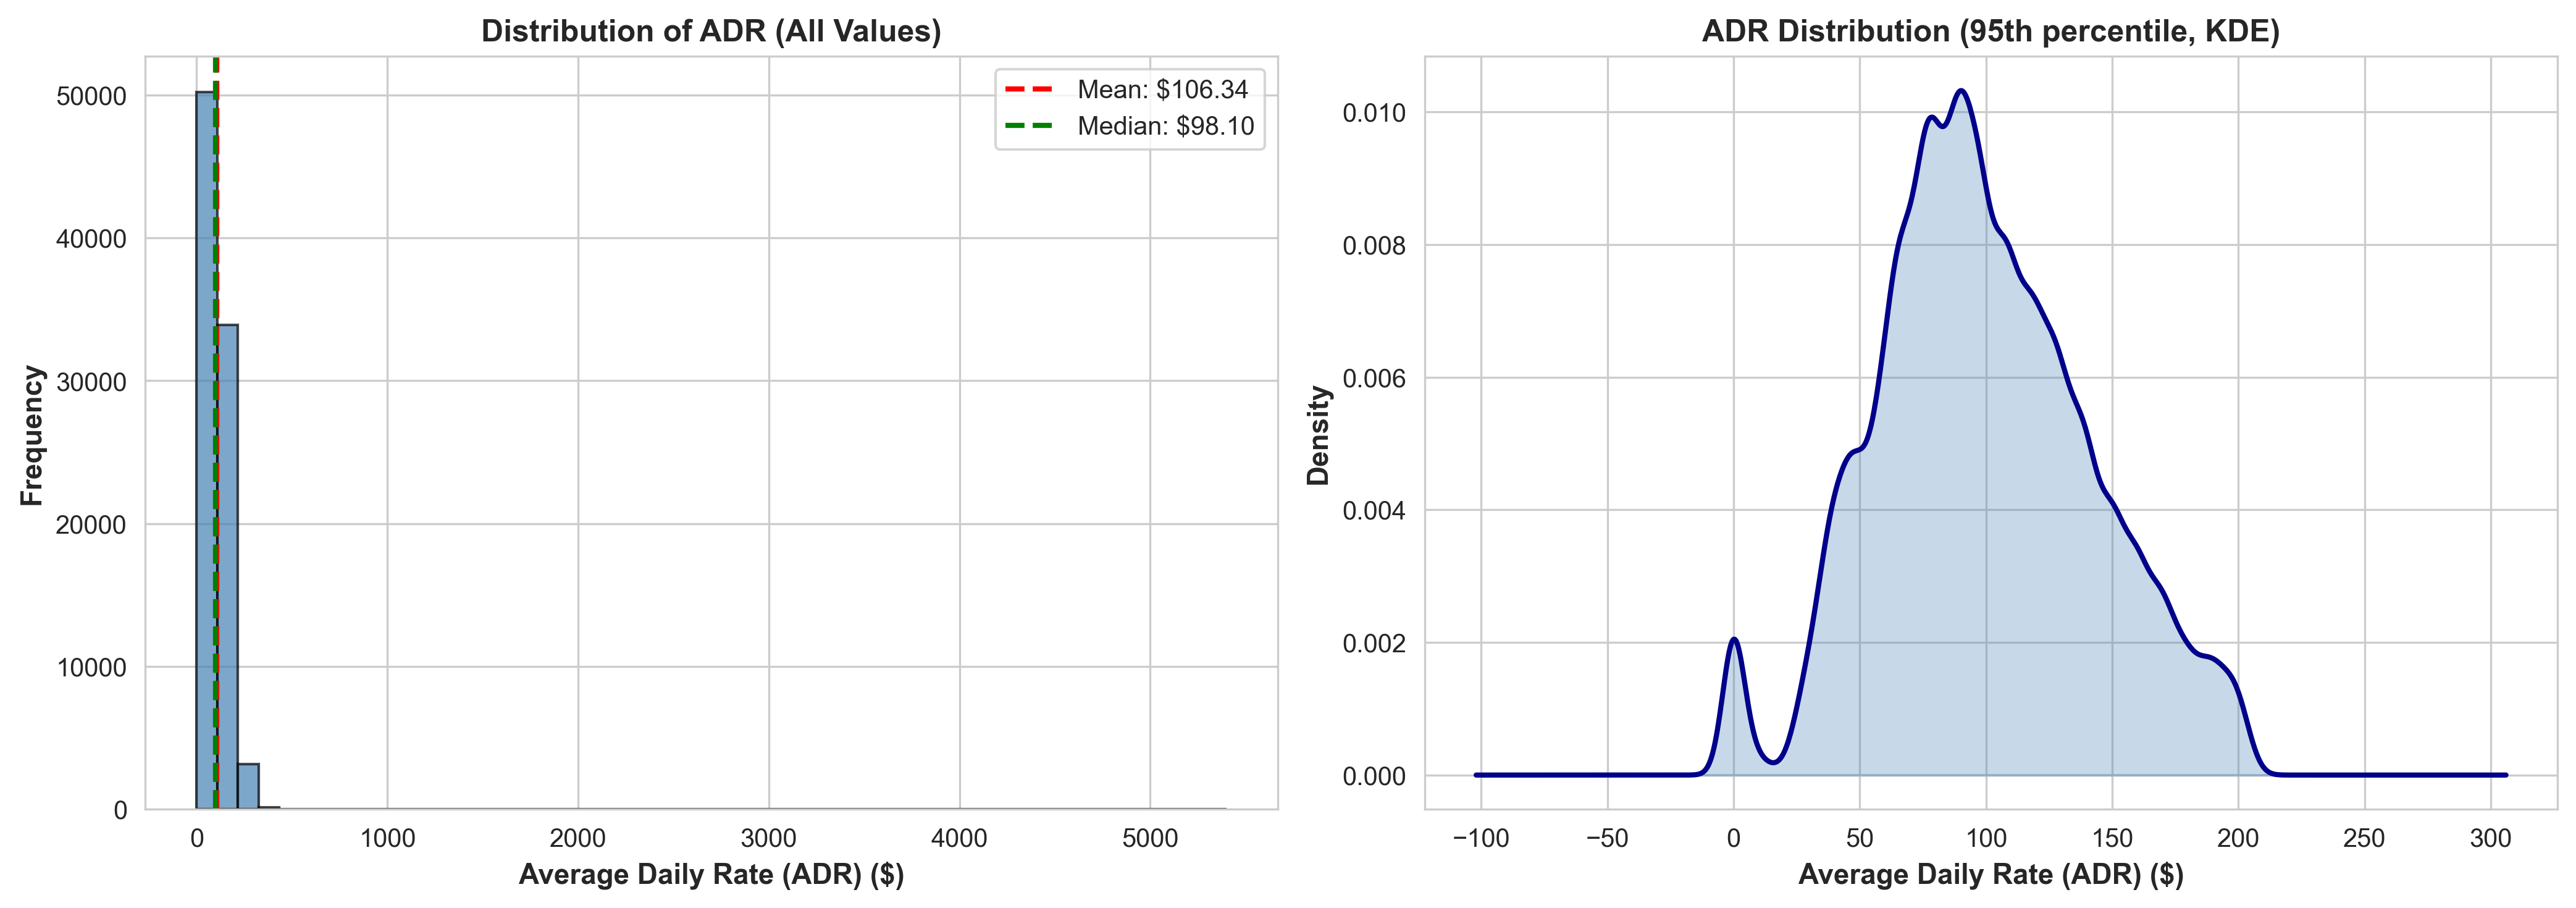

04_cancellation_impact.png


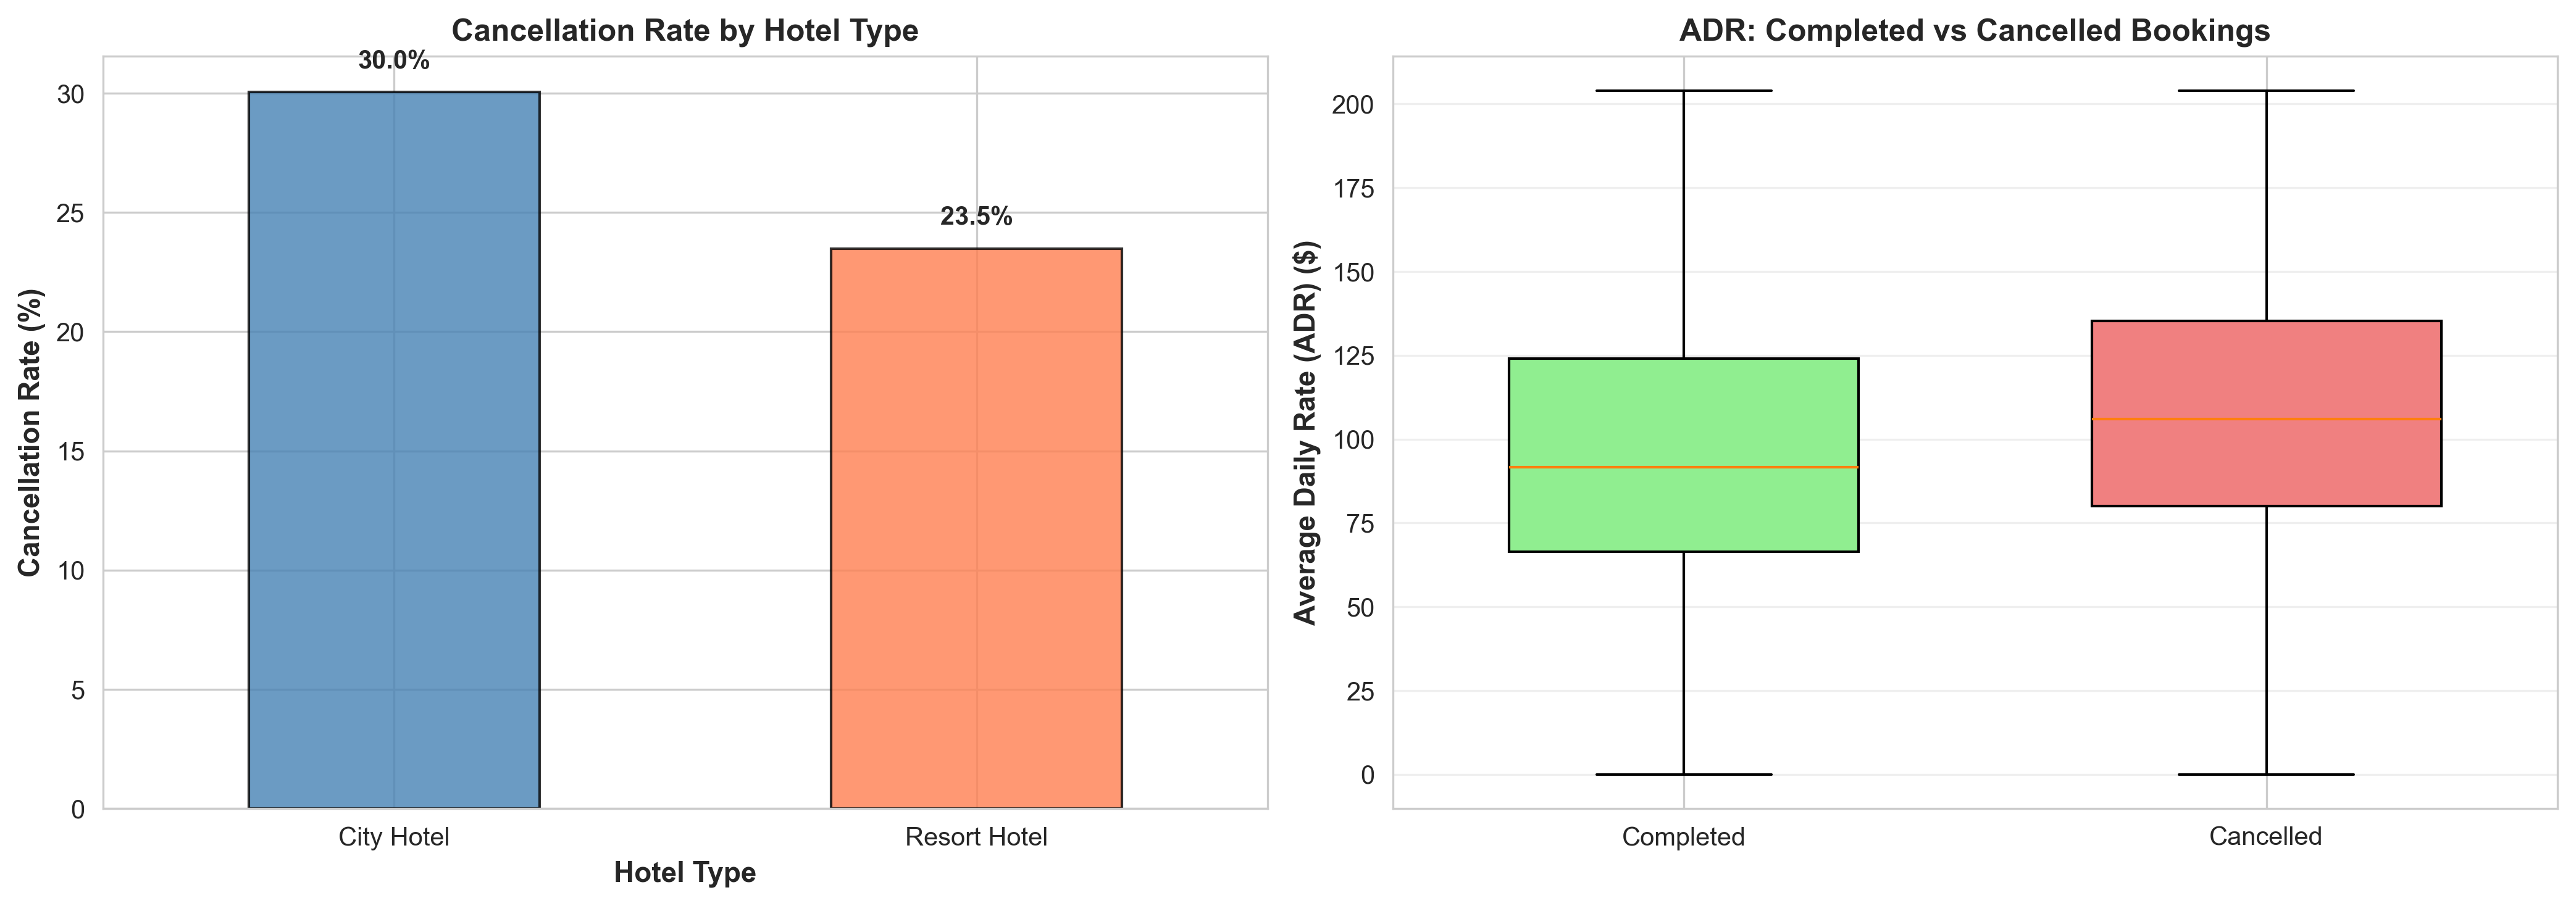

06_seasonal_trends.png


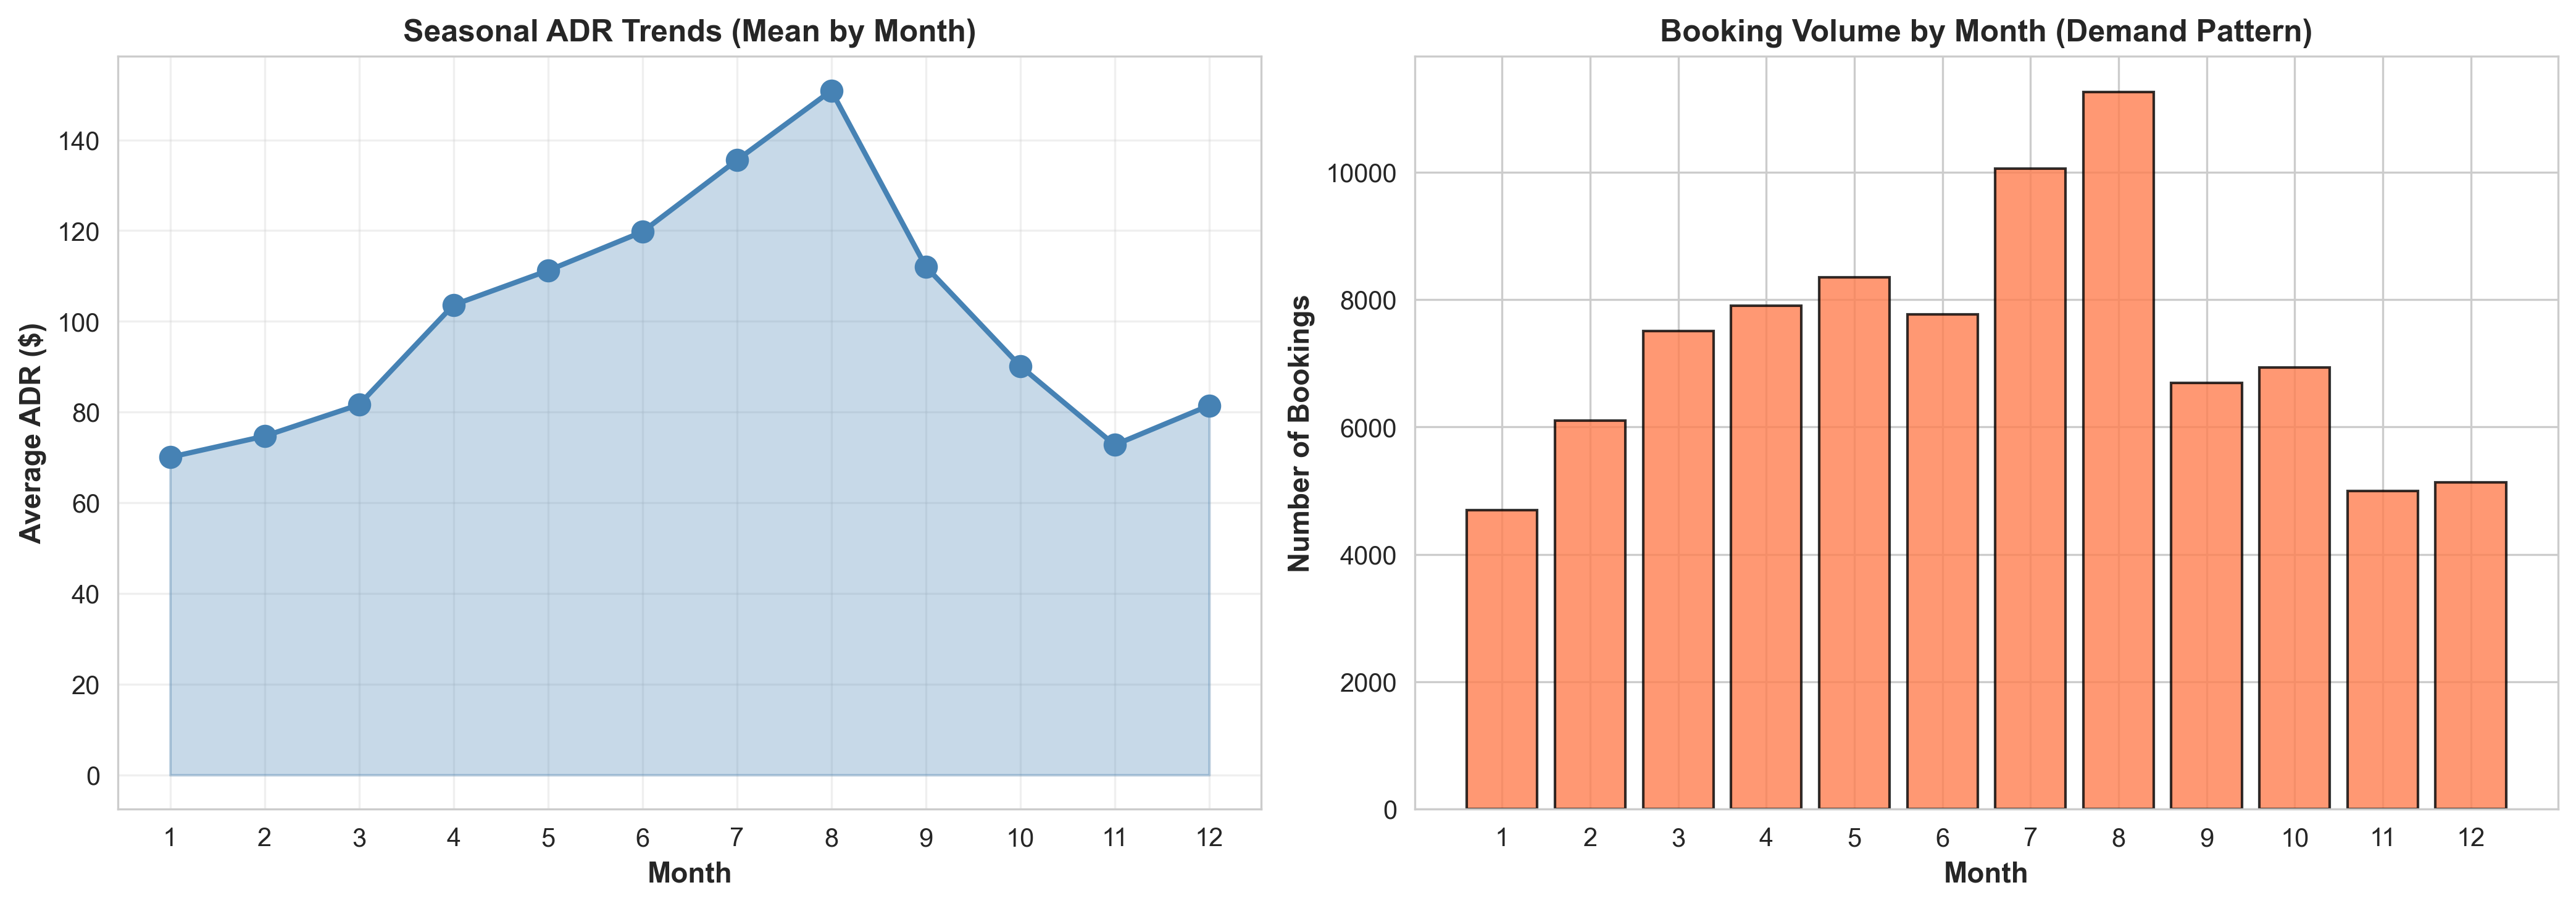

07_market_segment_analysis.png


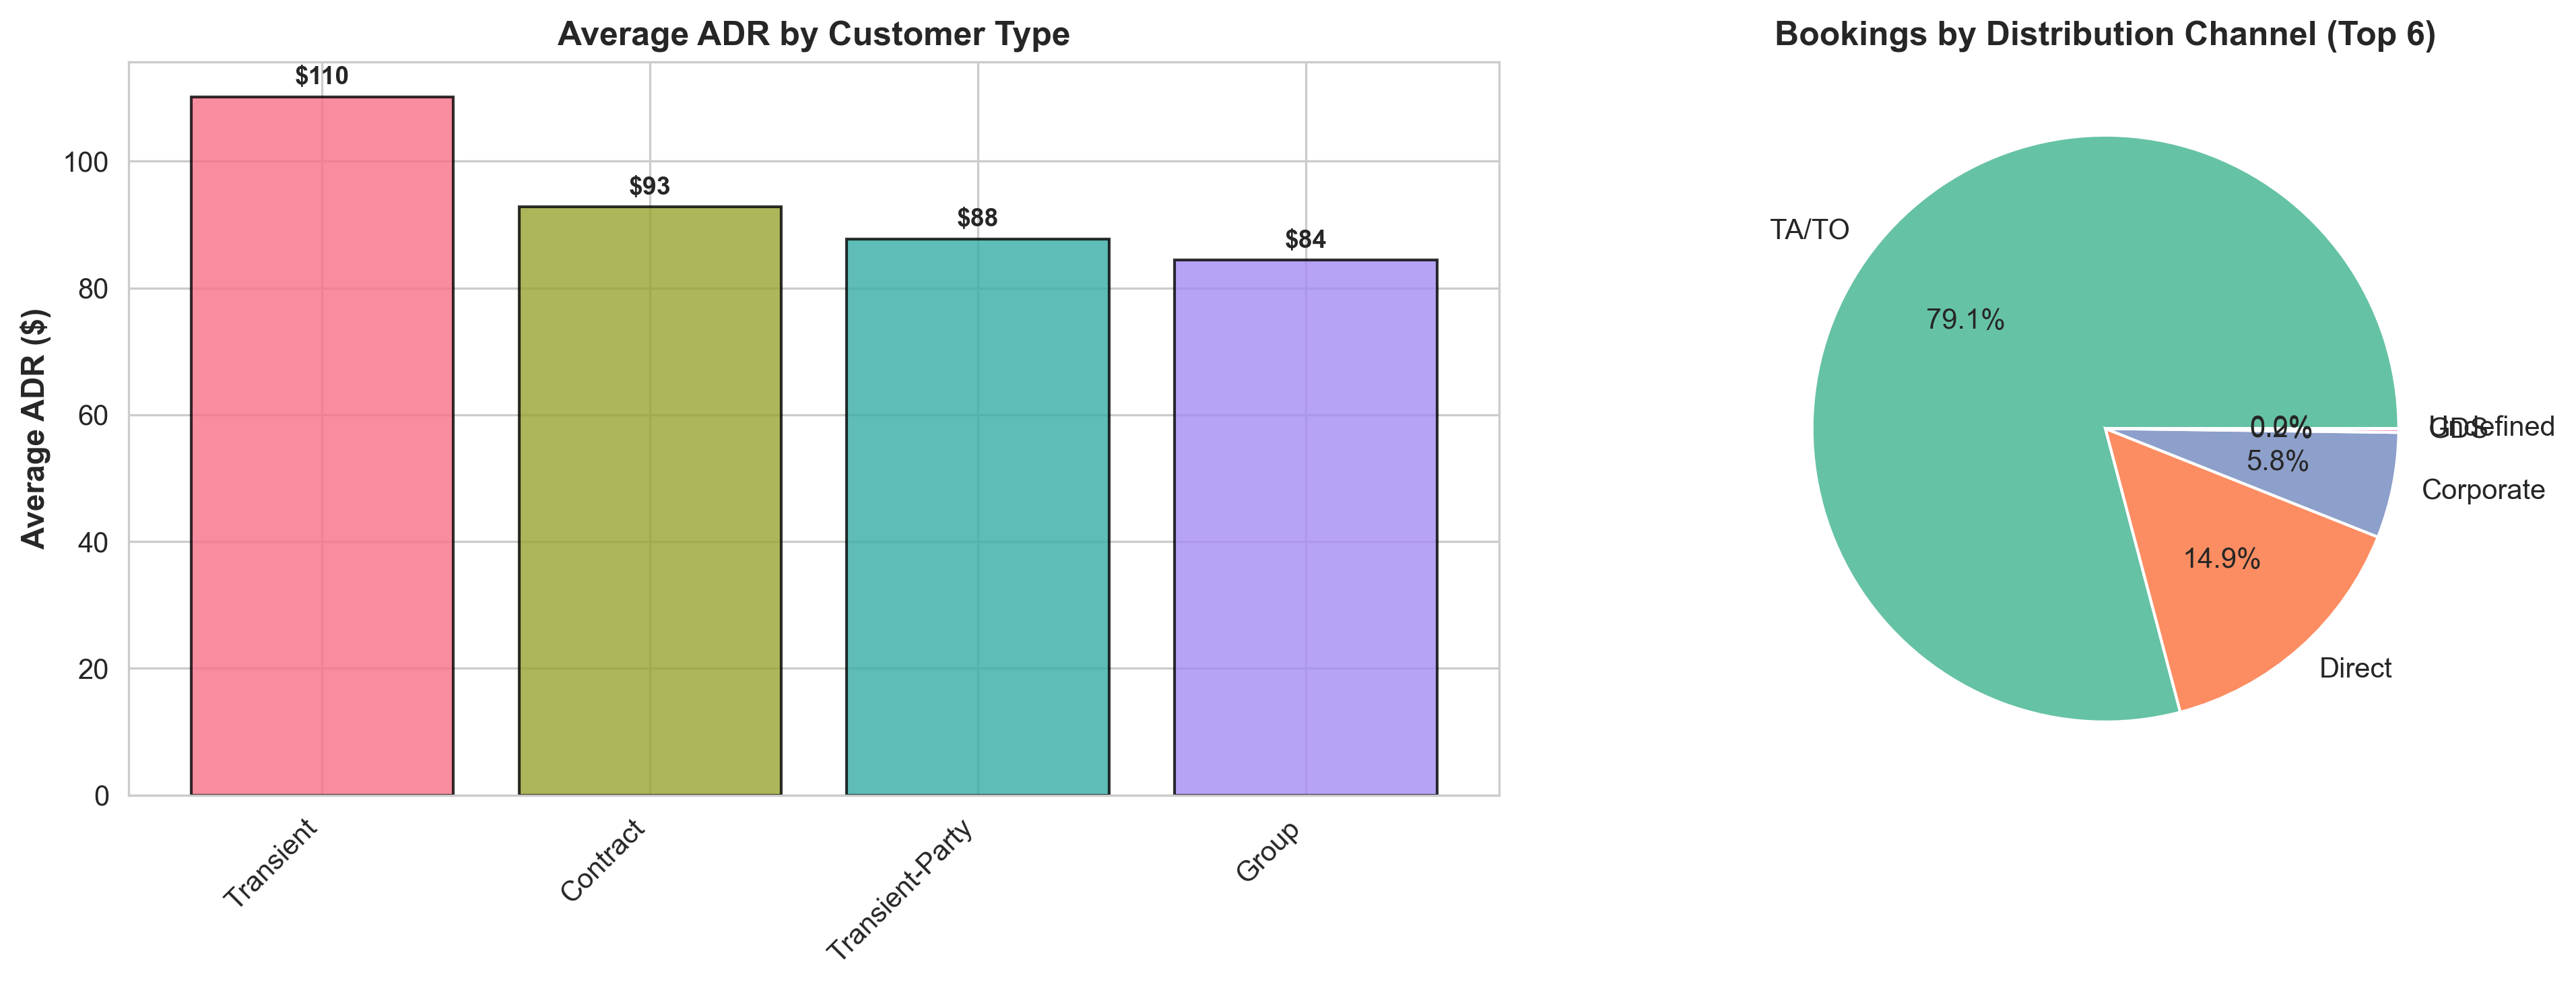

08_correlation_heatmap.png


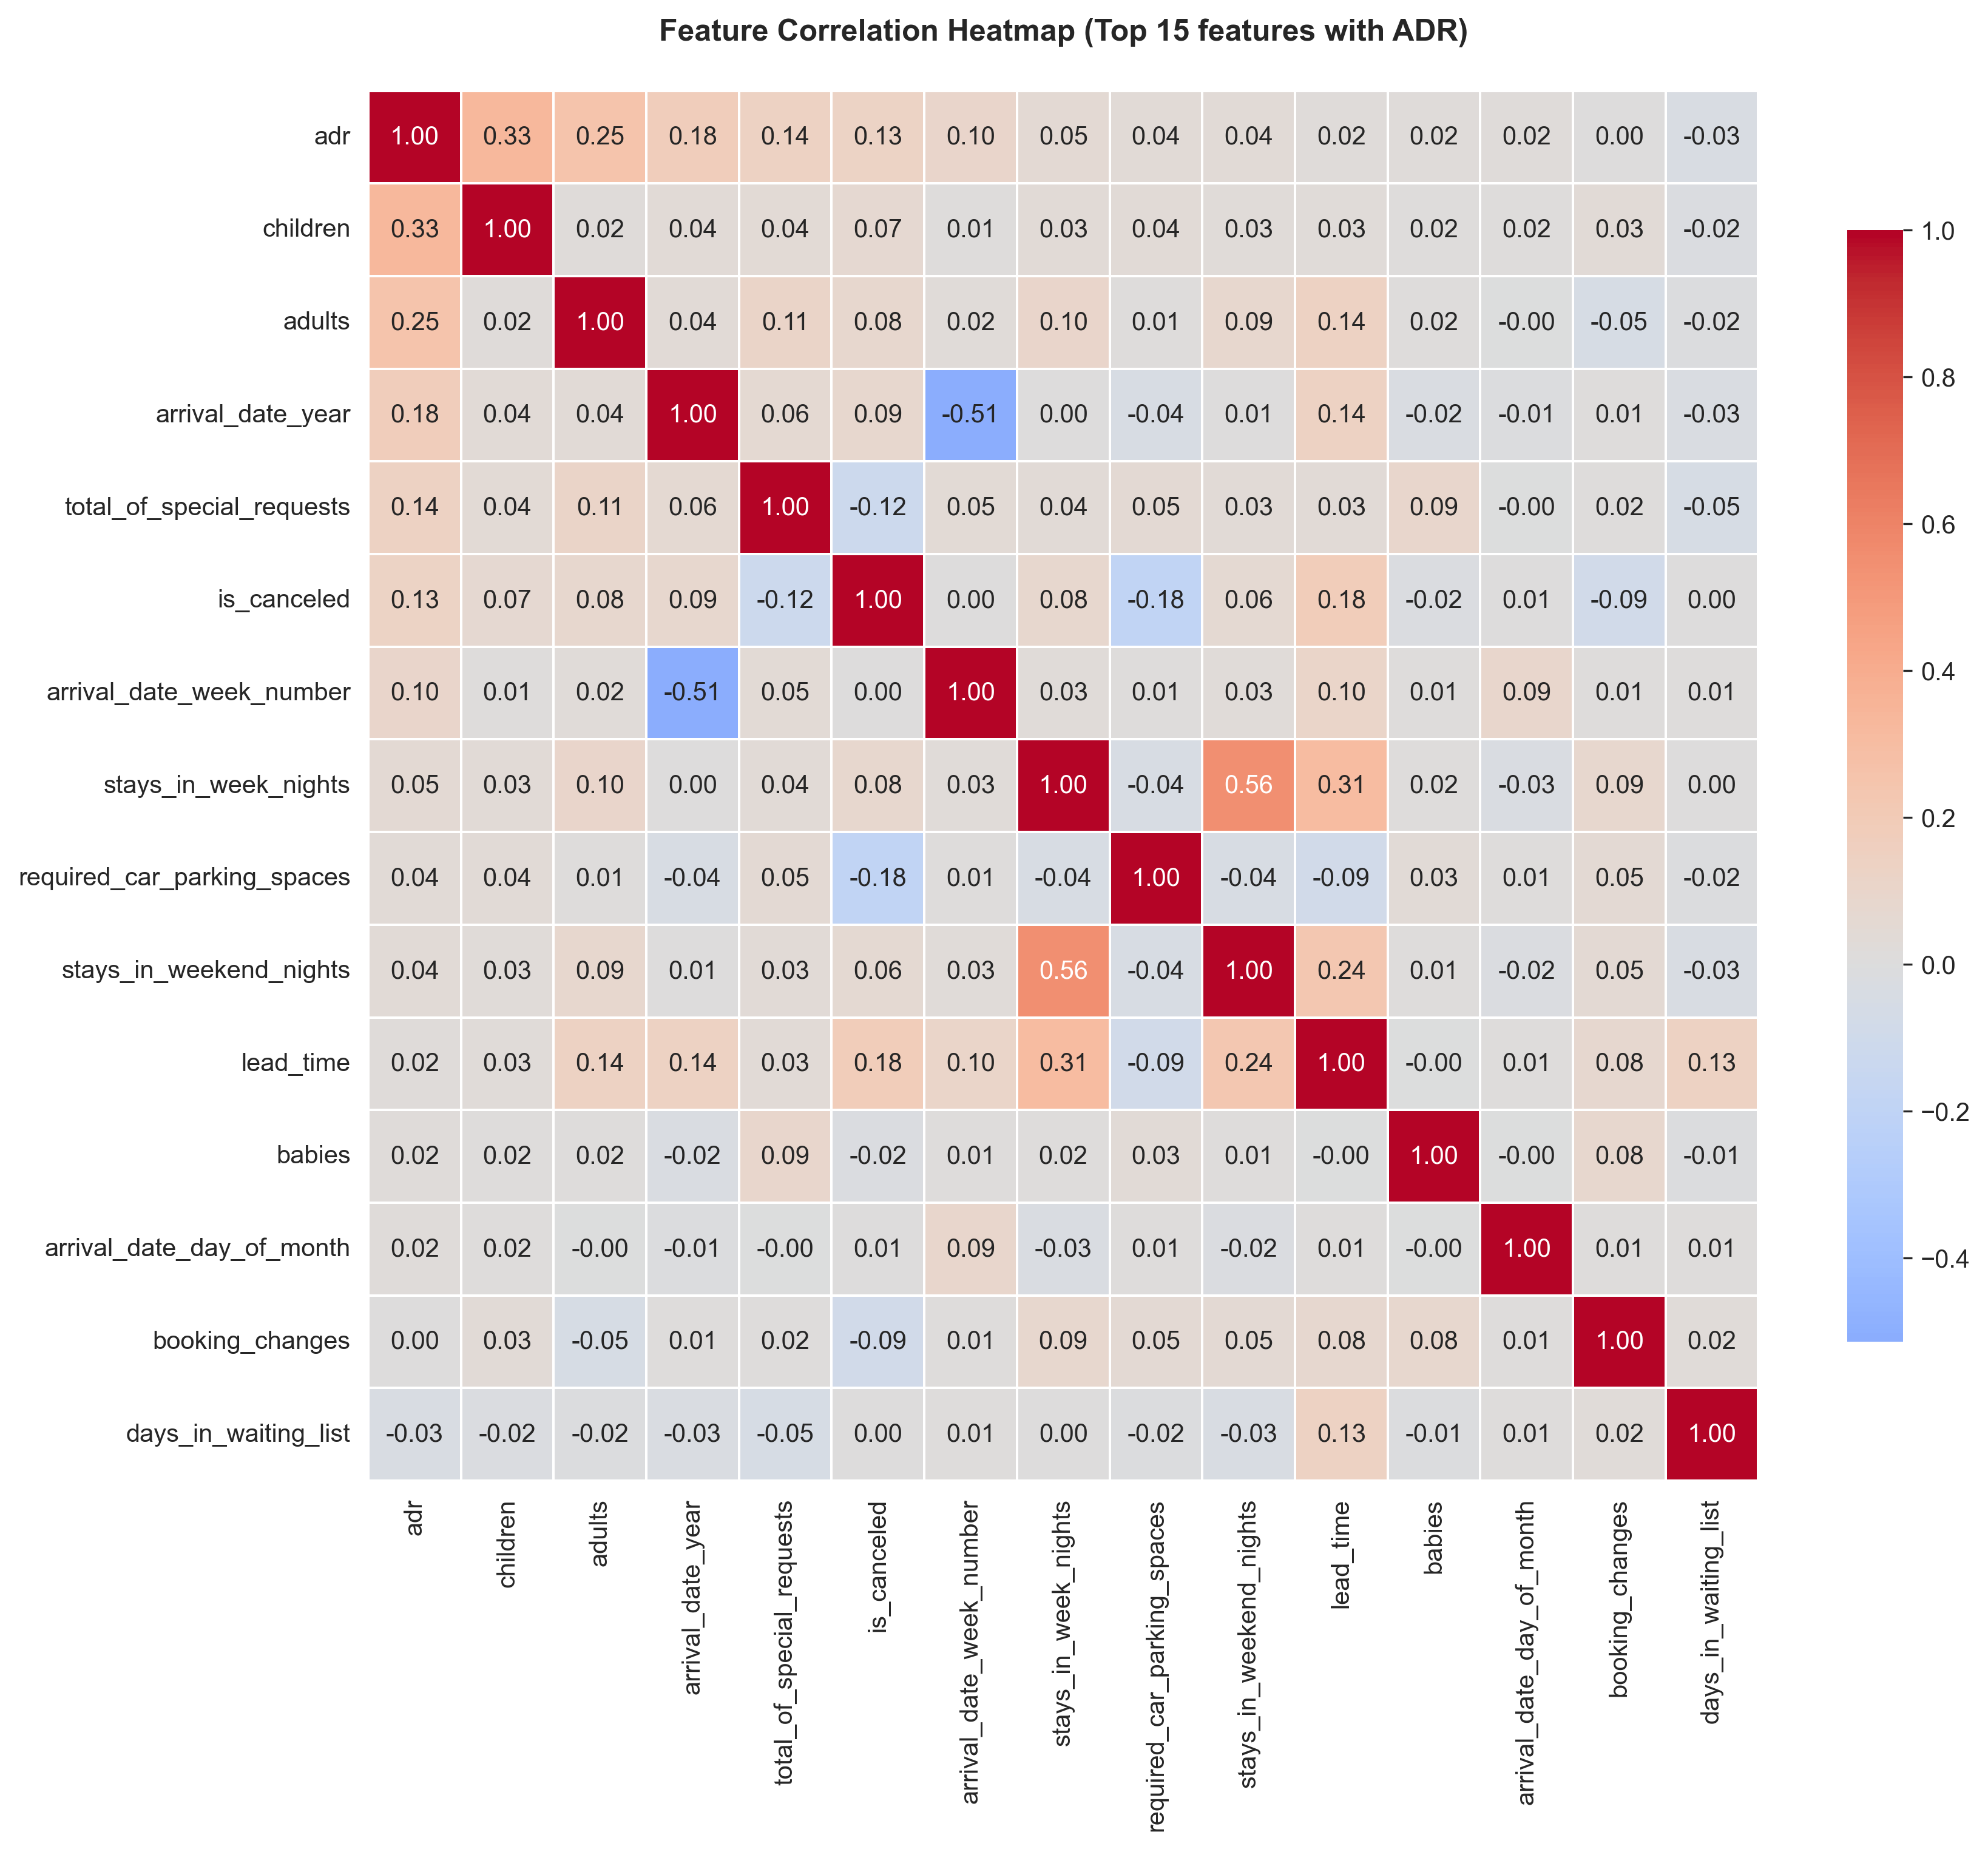

In [5]:
# Display a representative subset inline (full set lives in reports/).
eda_figs = [
    "01_adr_distribution.png", "04_cancellation_impact.png",
    "06_seasonal_trends.png", "07_market_segment_analysis.png",
    "08_correlation_heatmap.png",
]
for fig in eda_figs:
    p = REPORTS / fig
    if p.exists():
        print(fig)
        display(Image(filename=str(p), width=720))

## 5. Model Training

In [6]:
X_train, X_test, y_train, y_test = build_splits(df, target="adr")
print(f"Train: {X_train.shape}, Test: {X_test.shape}, Features: {X_train.shape[1]}")

# Trains LinearRegression, RandomForest, and XGBoost (or GradientBoosting fallback).
models, metrics_df = train_and_compare(X_train, y_train, X_test, y_test)
list(models.keys())

Train: (20000, 60), Test: (5000, 60), Features: 60


['LinearRegression', 'RandomForest', 'XGBoost']

## 6. Evaluation Metrics

In [7]:
csv_path = save_comparison(metrics_df, REPORTS)
print("Saved:", csv_path)
print("\n=== Model comparison (test set) ===")
print(metrics_df.to_string(index=False))

best_overall = metrics_df.iloc[0]
print(f"\nBest model: {best_overall['model']} "
      f"(R2={best_overall['R2']:.3f}, RMSE={best_overall['RMSE']:.2f}, MAE={best_overall['MAE']:.2f})")
metrics_df

Saved: C:\Users\arjun\hotel_booking_and-conceirge_copilot\reports\model_comparison.csv

=== Model comparison (test set) ===
           model       R2      RMSE       MAE
    RandomForest 0.798445 23.283993 15.683294
         XGBoost 0.790451 23.741249 16.936517
LinearRegression 0.486147 37.177489 27.494926

Best model: RandomForest (R2=0.798, RMSE=23.28, MAE=15.68)


,model,R2,RMSE,MAE
0,RandomForest,0.798445,23.283993,15.683294
1,XGBoost,0.790451,23.741249,16.936517
2,LinearRegression,0.486147,37.177489,27.494926


## 7. SHAP Explainability

SHAP is computed for the best **tree-based** model on a sampled subset of the test
set (fast and memory-light). Two artifacts are saved to `reports/`:
`shap_feature_importance.png` (global bar) and `shap_summary.png` (beeswarm).

In [8]:
best_name, best_model = select_best_tree_model(metrics_df, models)
print("Explaining model:", best_name)

shap_values = compute_shap_values(best_model, X_test, sample_size=1000, random_state=42)
bar_path = plot_shap_bar(shap_values, REPORTS)
bee_path = plot_shap_beeswarm(shap_values, REPORTS)
print("Saved:", bar_path.name, "and", bee_path.name)

ranking = top_features(shap_values, n=10)
print("\nTop 10 features by mean |SHAP|:")
print(ranking.to_string())

Explaining model: RandomForest


Saved: shap_feature_importance.png and shap_summary.png

Top 10 features by mean |SHAP|:
                     feature  mean_abs_shap
1               total_guests      12.147737
2          arrival_month_num      10.830445
3         hotel_Resort Hotel       8.844599
4            arrival_quarter       7.833961
5   market_segment_Online TA       7.530308
6                    meal_HB       5.298571
7                  lead_time       5.235591
8          reservation_month       3.297033
9       reserved_room_type_D       3.220193
10     market_segment_Direct       3.024334


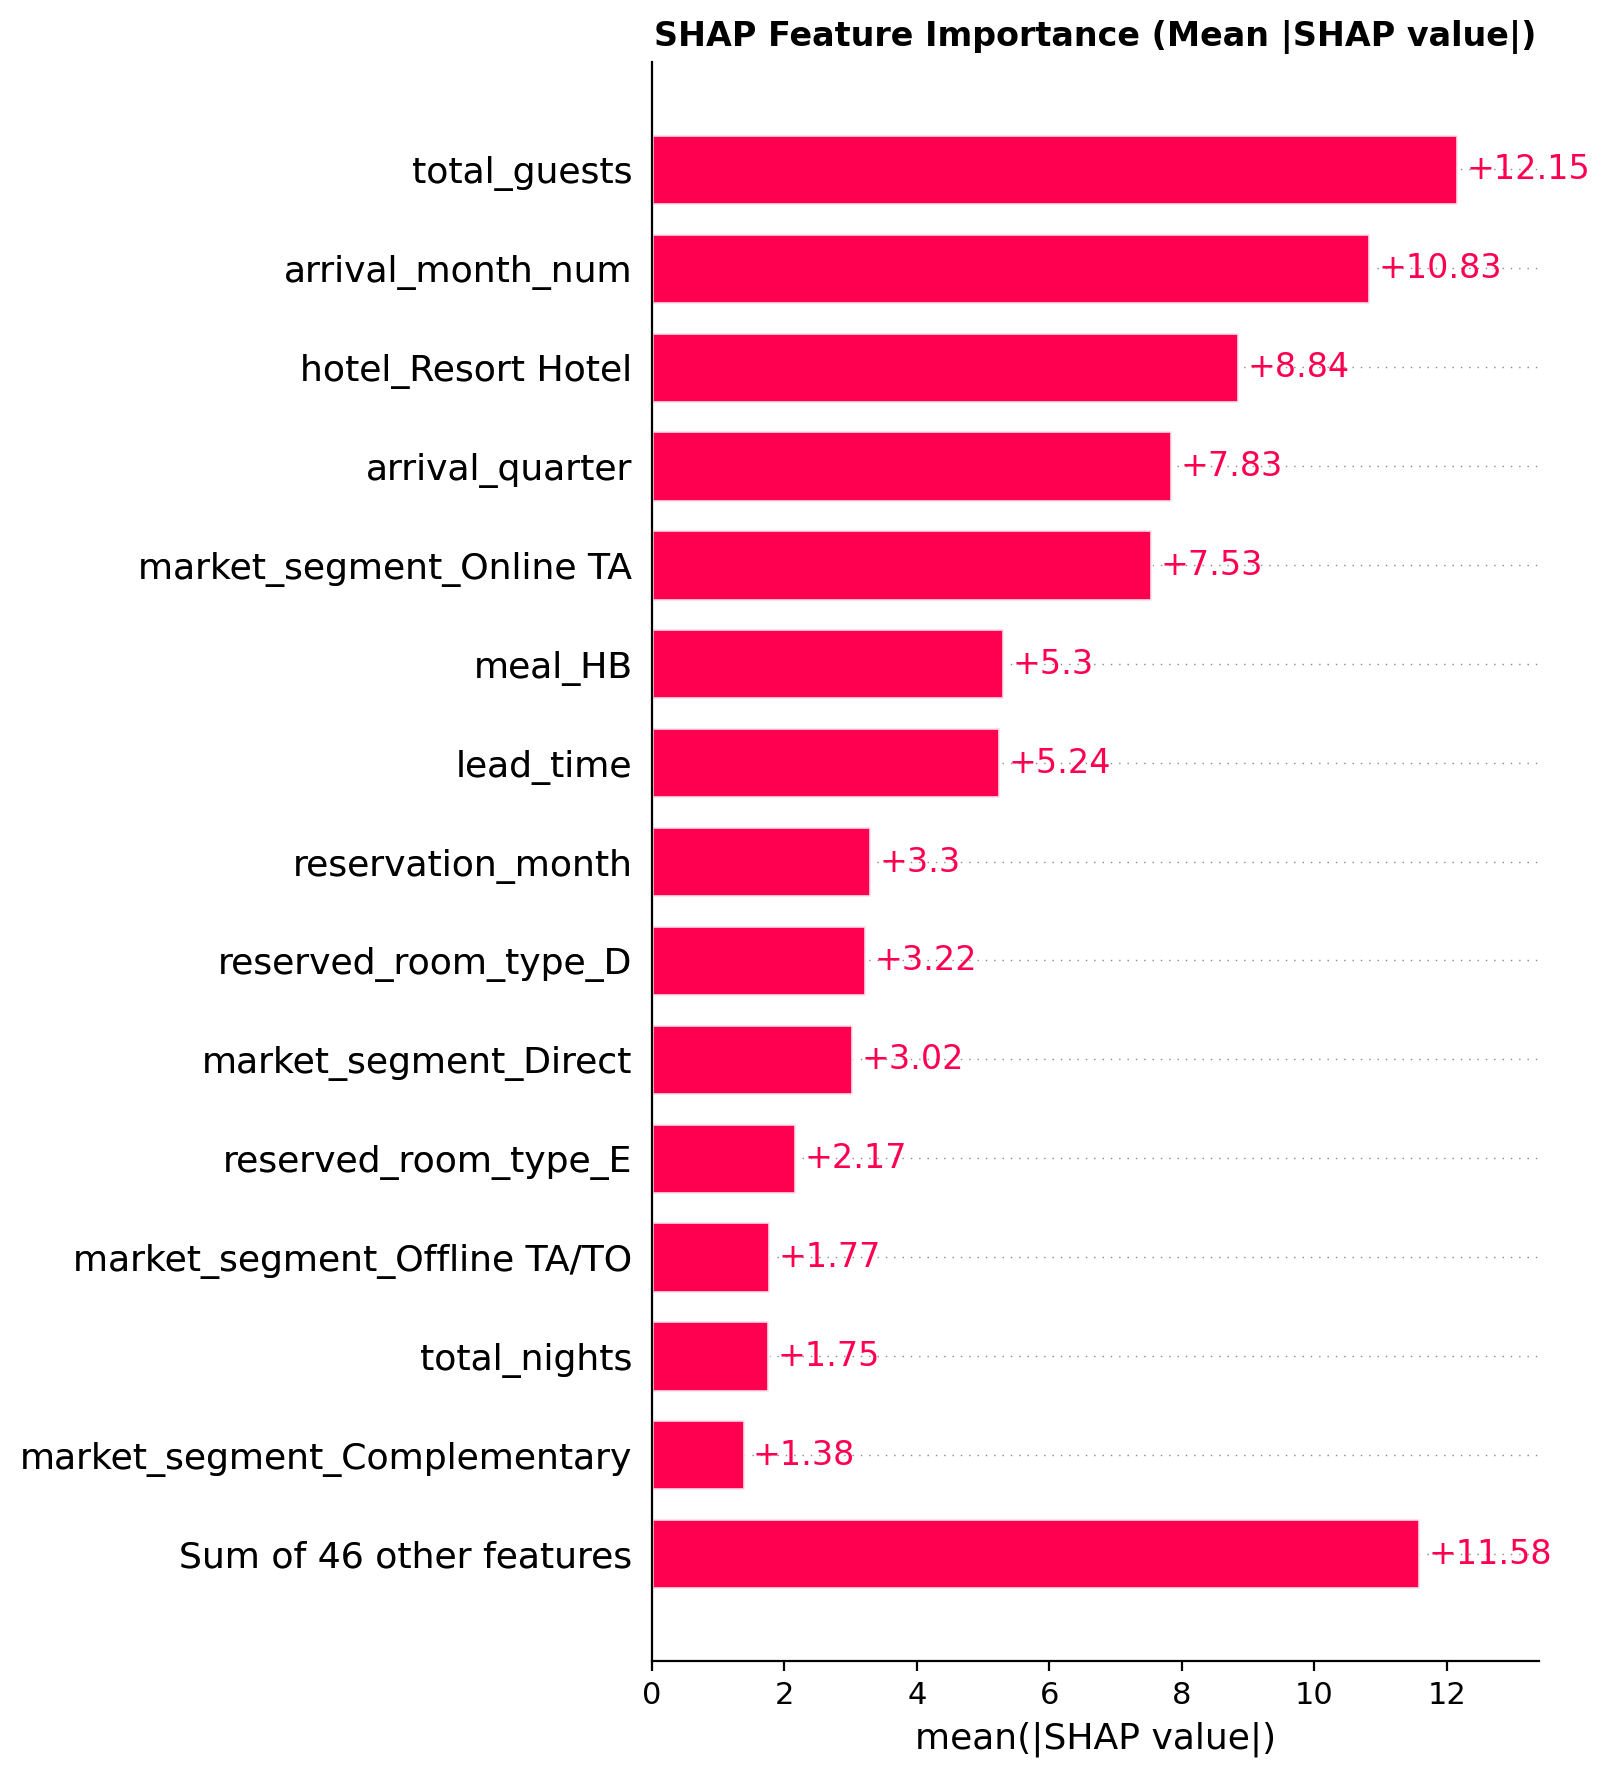

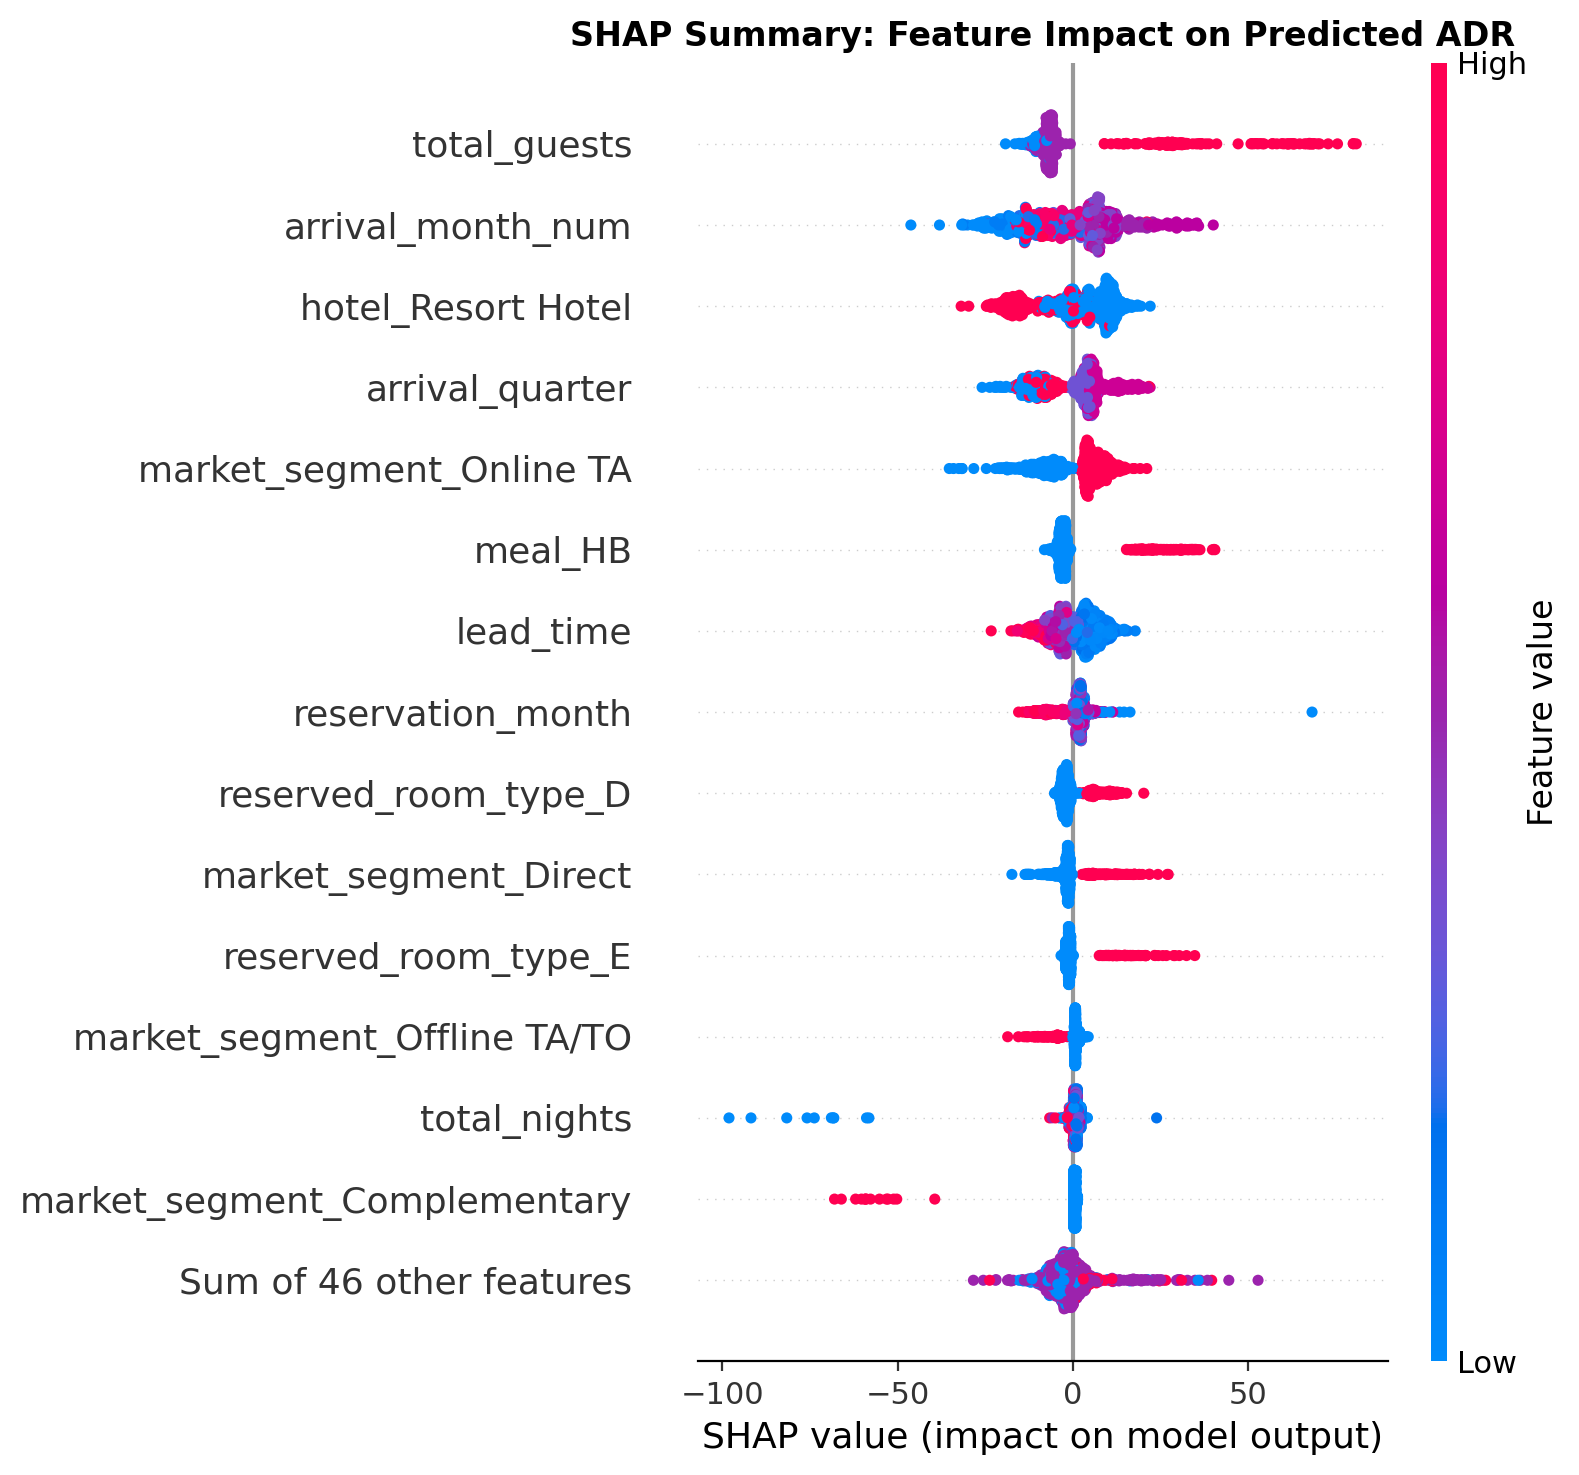

In [9]:
display(Image(filename=str(REPORTS / "shap_feature_importance.png"), width=720))
display(Image(filename=str(REPORTS / "shap_summary.png"), width=720))

## 8. Conclusion

- **Target:** Average Daily Rate (ADR), a meaningful revenue-management metric.
- **Best model:** RandomForest (≈0.80 R²), clearly beating Linear Regression (≈0.49 R²),
  showing ADR depends on non-linear interactions between booking attributes.
- **What drives ADR (SHAP):** party size (`total_guests`), seasonality
  (`arrival_month_num`, `arrival_quarter`), hotel type (`Resort Hotel`), booking
  channel (`market_segment_*`), board type (`meal_HB`) and `lead_time` are the
  strongest drivers — consistent with real hotel pricing dynamics.
- **Business use:** the model + SHAP can support dynamic pricing and revenue
  forecasting, with transparent, per-feature reasoning for each prediction.

All metrics are in `reports/model_comparison.csv`; SHAP plots are in `reports/`.